# 1. Isolation Forest and Supervised Baseline

This notebook handles the anomaly detection accuracy paradox using two tracks:

1. Optimized unsupervised Isolation Forest with a Precision-Recall threshold.
2. Supervised XGBoost or Random Forest with class imbalance handling.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler, MinMaxScaler

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False

RANDOM_STATE = 42
WINDOW_SIZE = 10
CLASS_NAMES = ["Normal", "Anomaly"]

sns.set_theme(style="darkgrid")

In [2]:
Data = pd.read_csv("../data/processed/Cleaned-Vehicle-Health-Telemetry-Dataset.csv")

Data["Row_Index"] = Data.index
Data["Timestamp"] = pd.to_datetime(Data["Timestamp"], errors="coerce")

print("Dataset shape:", Data.shape)
Data.head()

Dataset shape: (604800, 18)


,Timestamp,Engine_RPM,Vehicle_Speed,Coolant_Temp,Oil_Pressure,Vibration_Z,Engine_Load,Fuel_Rate,Intake_Air_Temp,Battery_Voltage,Throttle_Position,Ambient_Temp,Brake_Pressure,Acceleration_X,Acceleration_Y,Fault_Label,Fault_Type,Row_Index
0,2026-06-01 00:00:00,0.0,0.0,21.259663,1.661008,0.013402,0.0,0.0,21.933113,12.488478,0.0,21.446732,0.5,0.0,0.0,0.0,Normal,0
1,2026-06-01 00:00:01,0.0,0.0,21.259663,1.653945,0.012205,0.0,0.0,21.702260,12.488286,0.0,21.408633,0.5,0.0,0.0,0.0,Normal,1
2,2026-06-01 00:00:02,0.0,0.0,21.305162,1.453309,0.013224,0.0,0.0,21.794081,12.490938,0.0,21.425312,0.5,0.0,0.0,0.0,Normal,2
3,2026-06-01 00:00:03,0.0,0.0,21.384146,1.384312,0.013470,0.0,0.0,21.508731,12.497744,0.0,21.491175,0.5,0.0,0.0,0.0,Normal,3
4,2026-06-01 00:00:04,0.0,0.0,21.387741,1.865632,0.010776,0.0,0.0,21.785657,12.496880,0.0,21.438434,0.5,0.0,0.0,0.0,Normal,4


In [3]:
columns_to_drop = ["Timestamp", "Fault_Label", "Fault_Type", "Row_Index"]

sensor_columns = []
for col in Data.select_dtypes(include=[np.number]).columns:
    if col not in columns_to_drop:
        sensor_columns.append(col)

Model_Data = Data.copy()

for col in sensor_columns:
    Model_Data[col + "_rolling_mean"] = Model_Data[col].rolling(window=WINDOW_SIZE).mean()
    Model_Data[col + "_rolling_std"] = Model_Data[col].rolling(window=WINDOW_SIZE).std()
    Model_Data[col + "_diff"] = Model_Data[col].diff()

Model_Data.dropna(inplace=True)
Model_Data.reset_index(drop=True, inplace=True)

feature_columns = []
for col in Model_Data.select_dtypes(include=[np.number]).columns:
    if col not in columns_to_drop:
        feature_columns.append(col)

print("Sensor columns:", len(sensor_columns))
print("Feature columns:", len(feature_columns))
print("Rows after feature engineering:", Model_Data.shape[0])

Model_Data.head()

Sensor columns: 14
Feature columns: 56
Rows after feature engineering: 604791


,Timestamp,Engine_RPM,Vehicle_Speed,Coolant_Temp,Oil_Pressure,Vibration_Z,Engine_Load,Fuel_Rate,Intake_Air_Temp,Battery_Voltage,...,Ambient_Temp_diff,Brake_Pressure_rolling_mean,Brake_Pressure_rolling_std,Brake_Pressure_diff,Acceleration_X_rolling_mean,Acceleration_X_rolling_std,Acceleration_X_diff,Acceleration_Y_rolling_mean,Acceleration_Y_rolling_std,Acceleration_Y_diff
0,2026-06-01 00:00:09,0.0,0.0,21.461930,3.076489,0.010845,0.0,0.0,21.753450,12.494118,...,0.010643,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2026-06-01 00:00:10,0.0,0.0,21.457727,3.218758,0.011300,0.0,0.0,21.366182,12.494041,...,-0.051844,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2026-06-01 00:00:11,0.0,0.0,21.419282,2.689689,0.010820,0.0,0.0,21.288149,12.496378,...,-0.041614,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2026-06-01 00:00:12,0.0,0.0,21.383937,3.129370,0.012646,0.0,0.0,21.196148,12.498199,...,0.009170,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2026-06-01 00:00:13,0.0,0.0,21.382525,2.575635,0.012879,0.0,0.0,21.102061,12.505955,...,-0.121978,0.5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
X = Model_Data[feature_columns]
y = (Model_Data["Fault_Label"] >= 1).astype(int)

actual_anomaly_ratio = float(y.mean())
actual_normal_ratio = 1 - actual_anomaly_ratio
majority_class_accuracy = float((y == 0).mean())

print("Class distribution:")
print(y.value_counts().sort_index())
print("Actual anomaly ratio:", round(actual_anomaly_ratio, 5))
print("Normal ratio:", round(actual_normal_ratio, 5))
print("Majority-class baseline accuracy:", round(majority_class_accuracy, 5))

Class distribution:
Fault_Label
0    592507
1     12284
Name: count, dtype: int64
Actual anomaly ratio: 0.02031
Normal ratio: 0.97969
Majority-class baseline accuracy: 0.97969


In [5]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val,
    y_train_val,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_train_val
)

print("Train shape:", X_train.shape, "Class 1 ratio:", round(float(y_train.mean()), 5))
print("Validation shape:", X_val.shape, "Class 1 ratio:", round(float(y_val.mean()), 5))
print("Test shape:", X_test.shape, "Class 1 ratio:", round(float(y_test.mean()), 5))

Train shape: (362874, 56) Class 1 ratio: 0.02031
Validation shape: (120958, 56) Class 1 ratio: 0.02031
Test shape: (120959, 56) Class 1 ratio: 0.02031


In [6]:
scaler = RobustScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)
X_all_scaled = scaler.transform(X)

print("Scaled train shape:", X_train_scaled.shape)
print("Scaled validation shape:", X_val_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaled train shape: (362874, 56)
Scaled validation shape: (120958, 56)
Scaled test shape: (120959, 56)


In [7]:
if_contamination = actual_anomaly_ratio
if_contamination = max(0.001, min(if_contamination, 0.50))

IF_Model = IsolationForest(
    n_estimators=200,
    contamination=if_contamination,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

IF_Model.fit(X_train_scaled)

print("Isolation Forest trained")
print("Contamination used:", round(if_contamination, 5))

Isolation Forest trained
Contamination used: 0.02031


In [8]:
IF_Val_Normality_Score = IF_Model.decision_function(X_val_scaled)
IF_Val_Anomaly_Score = -IF_Val_Normality_Score

if_precision, if_recall, if_thresholds = precision_recall_curve(y_val, IF_Val_Anomaly_Score)
if_f1_scores = (2 * if_precision * if_recall) / (if_precision + if_recall + 1e-12)

best_if_index = np.argmax(if_f1_scores[:-1])
best_if_threshold = if_thresholds[best_if_index]

print("Best Isolation Forest threshold:", best_if_threshold)
print("Validation precision at threshold:", round(if_precision[best_if_index], 4))
print("Validation recall at threshold:", round(if_recall[best_if_index], 4))
print("Validation F1 at threshold:", round(if_f1_scores[best_if_index], 4))

Best Isolation Forest threshold: -0.21372743567245084
Validation precision at threshold: 0.1599
Validation recall at threshold: 0.9288
Validation F1 at threshold: 0.2728


In [9]:
IF_Test_Normality_Score = IF_Model.decision_function(X_test_scaled)
IF_Test_Anomaly_Score = -IF_Test_Normality_Score

IF_Test_Pred = (IF_Test_Anomaly_Score >= best_if_threshold).astype(int)

print("Optimized Isolation Forest classification report:")
print(classification_report(y_test, IF_Test_Pred, labels=[0, 1], target_names=CLASS_NAMES, zero_division=0))

IF_Report = classification_report(
    y_test,
    IF_Test_Pred,
    labels=[0, 1],
    target_names=CLASS_NAMES,
    zero_division=0,
    output_dict=True
)

print("Class 1 precision:", round(IF_Report["Anomaly"]["precision"], 4))
print("Class 1 recall:", round(IF_Report["Anomaly"]["recall"], 4))
print("Class 1 F1-score:", round(IF_Report["Anomaly"]["f1-score"], 4))
print("Macro avg F1-score:", round(IF_Report["macro avg"]["f1-score"], 4))

Optimized Isolation Forest classification report:
              precision    recall  f1-score   support

      Normal       1.00      0.90      0.95    118502
     Anomaly       0.16      0.91      0.27      2457

    accuracy                           0.90    120959
   macro avg       0.58      0.91      0.61    120959
weighted avg       0.98      0.90      0.93    120959

Class 1 precision: 0.1575
Class 1 recall: 0.9125
Class 1 F1-score: 0.2686
Macro avg F1-score: 0.6072


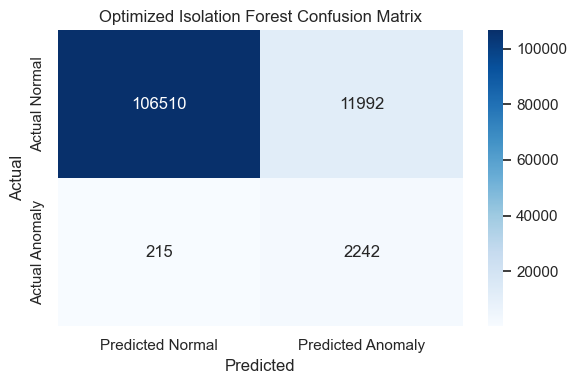

In [10]:
IF_CM = confusion_matrix(y_test, IF_Test_Pred, labels=[0, 1])

plt.figure(figsize=(6, 4))
sns.heatmap(
    IF_CM,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted Normal", "Predicted Anomaly"],
    yticklabels=["Actual Normal", "Actual Anomaly"]
)
plt.title("Optimized Isolation Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [11]:
IF_All_Raw_Anomaly_Score = -IF_Model.decision_function(X_all_scaled)
IF_All_Normalized_Anomaly_Score = MinMaxScaler().fit_transform(
    IF_All_Raw_Anomaly_Score.reshape(-1, 1)
).ravel()

Model_Data["IF_Anomaly_Score_Raw"] = IF_All_Raw_Anomaly_Score
Model_Data["IF_Anomaly_Score"] = IF_All_Normalized_Anomaly_Score
Model_Data["IF_Optimized_Anomaly_Flag"] = (IF_All_Raw_Anomaly_Score >= best_if_threshold).astype(int)
Model_Data["IF_Default_Anomaly_Flag"] = (IF_Model.predict(X_all_scaled) == -1).astype(int)

IF_Results = Model_Data[
    [
        "Row_Index",
        "Timestamp",
        "Engine_RPM",
        "Fault_Label",
        "Fault_Type",
        "IF_Anomaly_Score",
        "IF_Anomaly_Score_Raw",
        "IF_Optimized_Anomaly_Flag",
        "IF_Default_Anomaly_Flag"
    ]
].copy()

IF_Results.to_csv("IsolationForest_Anomaly_Scores.csv", index=False)

print("Saved IsolationForest_Anomaly_Scores.csv")
IF_Results.head()

Saved IsolationForest_Anomaly_Scores.csv


,Row_Index,Timestamp,Engine_RPM,Fault_Label,Fault_Type,IF_Anomaly_Score,IF_Anomaly_Score_Raw,IF_Optimized_Anomaly_Flag,IF_Default_Anomaly_Flag
0,9,2026-06-01 00:00:09,0.0,0.0,Normal,0.126023,-0.253899,0,0
1,10,2026-06-01 00:00:10,0.0,0.0,Normal,0.132369,-0.251039,0,0
2,11,2026-06-01 00:00:11,0.0,0.0,Normal,0.114429,-0.259123,0,0
3,12,2026-06-01 00:00:12,0.0,0.0,Normal,0.126526,-0.253672,0,0
4,13,2026-06-01 00:00:13,0.0,0.0,Normal,0.116418,-0.258227,0,0


In [12]:
LSTM_RESULTS_PATH = Path("LSTM_Anomaly_Results.csv")

if LSTM_RESULTS_PATH.exists():
    LSTM_Results = pd.read_csv(LSTM_RESULTS_PATH)

    if "Timestamp" in LSTM_Results.columns and "Row_Index" not in LSTM_Results.columns:
        LSTM_Results = LSTM_Results.rename(columns={"Timestamp": "Row_Index"})

    Fusion_Input = LSTM_Results.merge(
        IF_Results[
            [
                "Row_Index",
                "Timestamp",
                "Engine_RPM",
                "Fault_Label",
                "Fault_Type",
                "IF_Anomaly_Score",
                "IF_Optimized_Anomaly_Flag"
            ]
        ],
        on="Row_Index",
        how="inner"
    )

    Fusion_Input.to_csv("IF_LSTM_Fusion_Input.csv", index=False)

    print("Saved IF_LSTM_Fusion_Input.csv")
    print("Fusion shape:", Fusion_Input.shape)
    display(Fusion_Input.head())
else:
    print("LSTM_Anomaly_Results.csv was not found. Run the LSTM notebook first if fusion is needed.")

Saved IF_LSTM_Fusion_Input.csv
Fusion shape: (120950, 9)


,Row_Index,LSTM_Error,LSTM_Anomaly_Flag,Timestamp,Engine_RPM,Fault_Label,Fault_Type,IF_Anomaly_Score,IF_Optimized_Anomaly_Flag
0,483850,0.001330,0,2026-06-06 14:24:10,9.881313e-324,9.881313e-324,Normal,0.059255,0
1,483851,0.001341,0,2026-06-06 14:24:11,9.881313e-324,9.881313e-324,Normal,0.049310,0
2,483852,0.001284,0,2026-06-06 14:24:12,9.881313e-324,9.881313e-324,Normal,0.075313,0
3,483853,0.001263,0,2026-06-06 14:24:13,9.881313e-324,9.881313e-324,Normal,0.062789,0
4,483854,0.001245,0,2026-06-06 14:24:14,9.881313e-324,9.881313e-324,Normal,0.050701,0


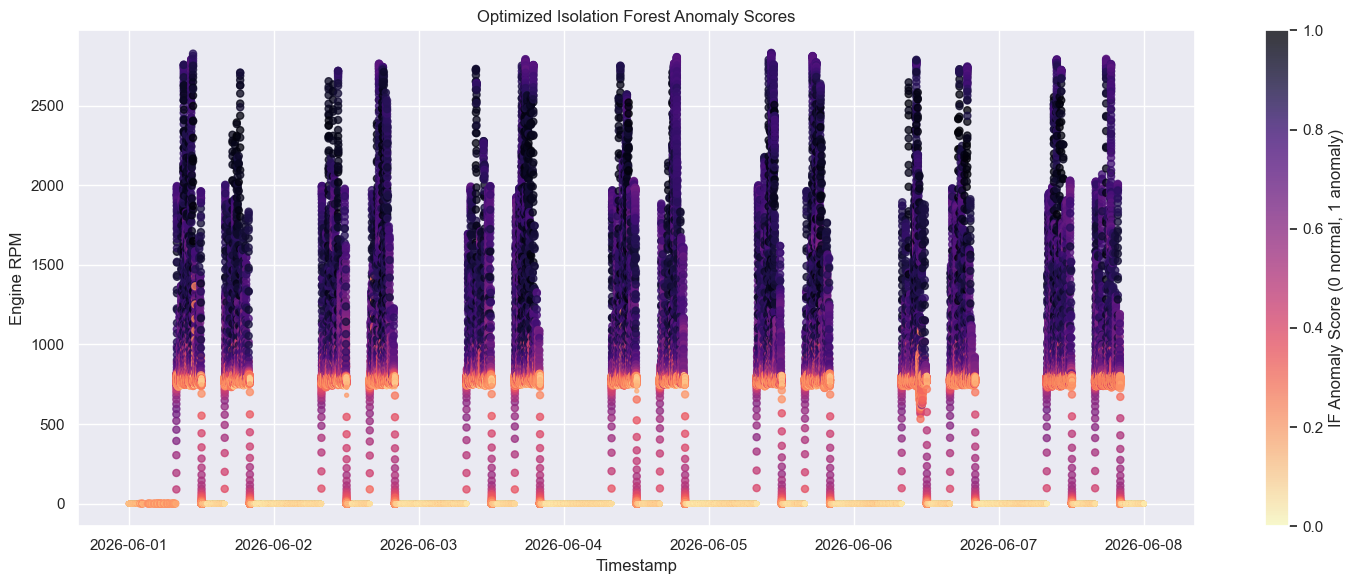

In [13]:
plt.figure(figsize=(15, 6))

plt.scatter(
    Model_Data["Timestamp"],
    Model_Data["Engine_RPM"],
    c=Model_Data["IF_Anomaly_Score"],
    cmap="magma_r",
    s=np.where(Model_Data["IF_Optimized_Anomaly_Flag"] == 1, 26, 8),
    alpha=0.75
)

plt.colorbar(label="IF Anomaly Score (0 normal, 1 anomaly)")
plt.title("Optimized Isolation Forest Anomaly Scores")
plt.xlabel("Timestamp")
plt.ylabel("Engine RPM")
plt.tight_layout()
plt.show()

In [14]:
import joblib
joblib.dump(IF_Model, 'if_model.pkl')

['if_model.pkl']